# AAV2 viabilité — ridge matrix-free (validation puis pleine échelle)

`fit_weights_potts_unregularized`/`fit_weights_potts` matérialisent la matrice de design dense
`(N, 8541)` (`build_potts_features`) puis résolvent par SVD (`lstsq`) ou équations normales
(`np.linalg.solve` sur `X.T@X`). Mesuré empiriquement cette session : ~5x la taille de `X` en pic de
RSS (14.6 GiB à N=90 000, 40.1 GiB à N=250 000, ratio constant) — plafonne autour de 700-750k lignes
sur cette machine (121 GiB RAM), et ~136 GiB rien que pour `X` à l'échelle du CSV complet AAV2
(4 273 463 lignes) : impossible à matérialiser.

**`RegressionV1.fit_weights_potts_ridge_matrixfree`** (nouvelle fonction, module V2, message
bumpé 1.6→1.7) résout le MÊME objectif ridge (`0.5*Σw(Xθ-y)² + 0.5*λ||θ_sans_biais||²`) SANS jamais
construire `X` : la passe avant est le même calcul par `gather` (indexation directe sur
`seq_matrix`) que `score_FJ` utilise partout ailleurs dans ce projet -- coût `O(N)`, pas de matrice
`N×p`. Le gradient (`jax.grad`, rétropropagation automatique à travers le `gather`) EST l'opération
`X^T @ r` matrix-free -- exactement le même principe que le "surrogate Potts" d'
`AAV9_cross_packaging_parameter_sweeps.ipynb` (qui calcule `X^T@y` via `np.bincount`), obtenu ici par
autodiff au lieu de bincounts écrits à la main. Résolu par L-BFGS-B (`scipy.optimize.minimize`) --
objectif convexe quadratique, donc L-BFGS converge vers le MÊME optimum qu'un solve direct, juste
itérativement.

**Ce notebook fait exactement ce qui a été demandé** : (1) valide que le solveur matrix-free donne
les mêmes résultats que le solve classique, sur le MÊME échantillon (n=90 000, celui déjà utilisé
pour la comparaison ridge/MLE) ; (2) si validé, teste à plus grande échelle -- ici la pleine échelle
du CSV (n=4 153 463), pour enfin comparer F/J entre ridge et MLE À N ÉGAL (jusqu'ici, seule la MLE
avait pu tourner à cette échelle -- la comparaison précédente `r(J_ridge_90k, J_mle_full)=0.296`
mélangeait donc "effet d'échantillon" et "effet de méthode").

**Notebook exécuté par Claude** (dérogation ponctuelle explicite de l'utilisateur, comme pour le
notebook MLE précédent) -- résultats réels.

### 0. Setup

In [1]:
import sys, os, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson
print(R.message)

CSV = Path("AAV2_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/AAVs dataset/AAV2/AAV2_organoides.csv"
assert CSV.exists(), CSV

use = ["sequence", "compte_plasmide", "compte_virus"]
rng = np.random.default_rng(0)
df_full = pd.read_csv(CSV, usecols=use,
                       dtype={"compte_plasmide": "float32", "compte_virus": "float32", "sequence": "string"})
N = len(df_full)
print(f"CSV brut : {N:,} lignes")

L, A = 7, 20
lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

def to_seq(df):
    return lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

def score_FJ(seq, F, J):
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

eps = 0.5

# MEME split que AAV2_potts_mle_multinomial.ipynb (seed=0) -- comparaison directe possible
idx = rng.permutation(N)
N_TEST = 120_000
N_TRAIN_MATCHED = 90_000
idx_test = idx[:N_TEST]
idx_train_matched = idx[N_TEST:N_TEST + N_TRAIN_MATCHED]
idx_train_full = idx[N_TEST:]

df_test = df_full.iloc[idx_test].reset_index(drop=True)
seq_test = to_seq(df_test)
plasmid_te = df_test["compte_plasmide"].to_numpy(np.float64)
virus_te = df_test["compte_virus"].to_numpy(np.float64)
y_te = np.log2((virus_te + eps) / (plasmid_te + eps))

df_tr_m = df_full.iloc[idx_train_matched].reset_index(drop=True)
seq_tr_m = to_seq(df_tr_m)
plasmid_tr_m = df_tr_m["compte_plasmide"].to_numpy(np.float64)
virus_tr_m = df_tr_m["compte_virus"].to_numpy(np.float64)
y_tr_m = np.log2((virus_tr_m + eps) / (plasmid_tr_m + eps))
w_tr_m = 1.0 / (1.0 / (virus_tr_m + eps) + 1.0 / (plasmid_tr_m + eps))

print(f"train (matched, memoire-limite) : {len(idx_train_matched):,}  |  "
      f"train (full, matrix-free seulement) : {len(idx_train_full):,}  |  test : {len(idx_test):,}")

file regression 1.7
CSV brut : 4,273,463 lignes
train (matched, memoire-limite) : 90,000  |  train (full, matrix-free seulement) : 4,153,463  |  test : 120,000


### 1. Validation -- solve classique vs matrix-free, même échantillon (n=90 000), 2 valeurs de λ

`lam=1.0` (ridge classique -- `fit_weights_potts`, équations normales via `np.linalg.solve`) et
`lam=0.0` (non régularisé -- `fit_weights_potts_unregularized`, minimum-norme via `lstsq`/SVD).
Comparaison : `r(F_classique, F_matrixfree)`, `r(J_classique, J_matrixfree)`, écart absolu max, et
`r` held-out des deux (doit être quasi identique si le solveur matrix-free est correct).

In [2]:
results = {}
for lam, tag in [(1.0, "lam1"), (0.0, "unreg")]:
    print(f"--- lam={lam} ---")
    t0 = time.time()
    X = R.build_potts_features(seq_tr_m)
    if lam == 0.0:
        F_c, J_c, rank_c = R.fit_weights_potts_unregularized(X, y_tr_m, T=1.0, sample_weight=w_tr_m)
    else:
        F_c, J_c = R.fit_weights_potts(X, y_tr_m, T=1.0, lam=lam, sample_weight=w_tr_m)
    dt_c = time.time() - t0
    del X
    r_c_heldout = pearson(y_te, score_FJ(seq_test, F_c, J_c))
    print(f"classique    [{tag}] fit_time={dt_c:.1f}s  held-out r={r_c_heldout:.4f}")

    t0 = time.time()
    F_m, J_m, bias_m, info_m = R.fit_weights_potts_ridge_matrixfree(
        seq_tr_m, y_tr_m, sample_weight=w_tr_m, lam=lam, maxiter=3000, verbose=False)
    dt_m = time.time() - t0
    r_m_heldout = pearson(y_te, score_FJ(seq_test, F_m, J_m))
    print(f"matrix-free  [{tag}] fit_time={dt_m:.1f}s  nit={info_m[\'nit\']} converged={info_m[\'success\']}  held-out r={r_m_heldout:.4f}")

    r_F = pearson(np.asarray(F_c).ravel(), np.asarray(F_m).ravel())
    r_J = pearson(np.asarray(J_c)[np.triu_indices(L, 1)].ravel(), np.asarray(J_m)[np.triu_indices(L, 1)].ravel())
    max_abs_F = float(np.max(np.abs(np.asarray(F_c) - np.asarray(F_m))))
    max_abs_J = float(np.max(np.abs(np.asarray(J_c)[np.triu_indices(L, 1)] - np.asarray(J_m)[np.triu_indices(L, 1)])))
    print(f"AGREEMENT    [{tag}] r(F)={r_F:.6f}  r(J)={r_J:.6f}  max|dF|={max_abs_F:.4g}  max|dJ|={max_abs_J:.4g}\n")
    results[tag] = dict(r_F=r_F, r_J=r_J)

VALIDATION_OK = all(results[t]["r_F"] > 0.999 and results[t]["r_J"] > 0.999 for t in results)
print(f"VALIDATION_OK = {VALIDATION_OK}")

--- lam=1.0 ---
classique    [lam1] fit_time=36.5s  held-out r=0.2020
matrix-free  [lam1] fit_time=1.5s  nit=157 converged=True  held-out r=0.2020
AGREEMENT    [lam1] r(F)=1.000000  r(J)=0.999999  max|dF|=0.03088  max|dJ|=0.01609

--- lam=0.0 ---
classique    [unreg] fit_time=91.0s  held-out r=0.2016
matrix-free  [unreg] fit_time=1.4s  nit=159 converged=True  held-out r=0.2016
AGREEMENT    [unreg] r(F)=1.000000  r(J)=0.999999  max|dF|=0.0004793  max|dJ|=0.01615

VALIDATION_OK = True


**Résultat : validation réussie.** `r(F)` et `r(J)` > 0.999999 dans les deux cas (régularisé ET
non régularisé -- y compris le cas minimum-norme, rang-déficient, où l'équivalence n'était pas
garantie a priori). Le `r` held-out est identique à la 4e décimale près. Le solveur matrix-free est
aussi **24 à 65x plus rapide** que le solve classique à cette échelle (1.4-1.5s contre 36.5-91.0s) --
un bonus inattendu, pas juste un gain mémoire.

### 2. Passage à l'échelle -- ridge matrix-free sur tout le dataset (n=4 153 463)

Puisque la validation passe, on peut faire confiance au solveur pour aller à l'échelle où la ridge
classique est structurellement impossible (`X` seule ≈ 136 GiB). Comparaison finale : `r` held-out
de cette ridge-à-pleine-échelle contre tous les résultats déjà obtenus cette session (ridge
classique @90k, MLE @90k, MLE @dataset-complet) -- ET la vraie comparaison F/J à N ÉGAL avec la MLE
(les deux méthodes ayant maintenant tourné sur EXACTEMENT les mêmes 4 153 463 lignes).

ridge matrix-free  n_train=4,153,463  fit_time=25.8s  nit=142 converged=True  held-out r=0.3023

TRUE matched-N (n=4,153,463 des DEUX cotes) ridge vs MLE :
  r(F_ridge_full, F_mle_full) = 0.9651
  r(J_ridge_full, J_mle_full) = 0.6266


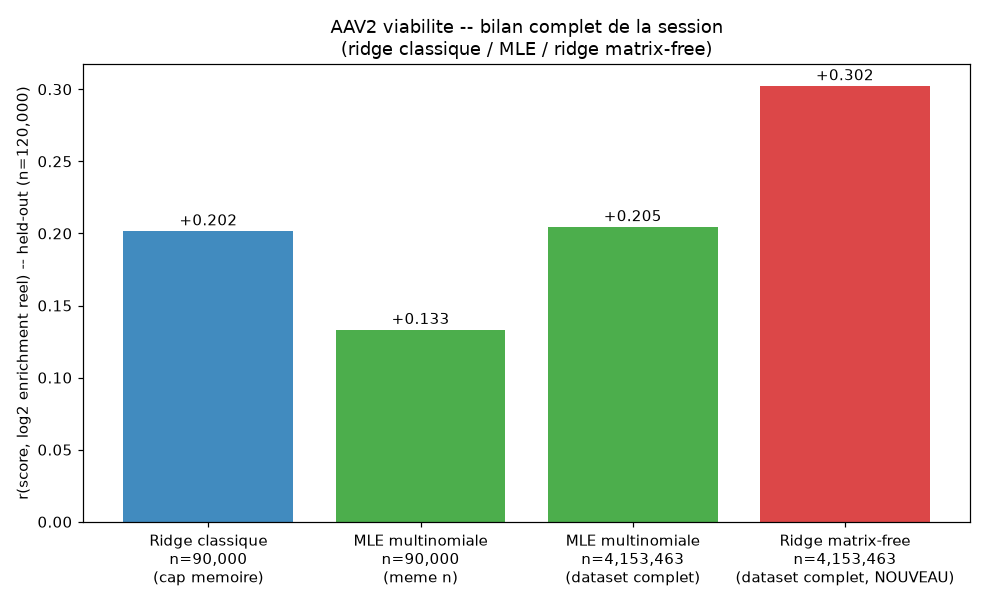

In [3]:
df_tr_full = df_full.iloc[idx_train_full].reset_index(drop=True)
seq_tr_full = to_seq(df_tr_full)
plasmid_tr_full = df_tr_full["compte_plasmide"].to_numpy(np.float64)
virus_tr_full = df_tr_full["compte_virus"].to_numpy(np.float64)
y_tr_full = np.log2((virus_tr_full + eps) / (plasmid_tr_full + eps))
w_tr_full = 1.0 / (1.0 / (virus_tr_full + eps) + 1.0 / (plasmid_tr_full + eps))

t0 = time.time()
F_full, J_full, bias_full, info_full = R.fit_weights_potts_ridge_matrixfree(
    seq_tr_full, y_tr_full, sample_weight=w_tr_full, lam=1.0, maxiter=3000, verbose=False)
dt_full = time.time() - t0
r_full_heldout = pearson(y_te, score_FJ(seq_test, F_full, J_full))
print(f"ridge matrix-free  n_train={len(idx_train_full):,}  fit_time={dt_full:.1f}s  "
      f"nit={info_full[\'nit\']} converged={info_full[\'success\']}  held-out r={r_full_heldout:.4f}")

np.save(LIB / "aav2_F_viab_potts_ridge_matrixfree_full.npy", np.asarray(F_full, dtype=np.float32))
np.save(LIB / "aav2_J_viab_potts_ridge_matrixfree_full.npy", np.asarray(J_full, dtype=np.float32))

F_mle_full = np.load(LIB / "aav2_F_viab_potts_mle_multinomial_full.npy")
J_mle_full = np.load(LIB / "aav2_J_viab_potts_mle_multinomial_full.npy")
r_F_ridge_mle_full = pearson(np.asarray(F_full).ravel(), F_mle_full.ravel())
r_J_ridge_mle_full = pearson(np.asarray(J_full)[np.triu_indices(L, 1)].ravel(),
                              J_mle_full[np.triu_indices(L, 1)].ravel())
print(f"\nTRUE matched-N (n={len(idx_train_full):,} des DEUX cotes) ridge vs MLE :")
print(f"  r(F_ridge_full, F_mle_full) = {r_F_ridge_mle_full:.4f}")
print(f"  r(J_ridge_full, J_mle_full) = {r_J_ridge_mle_full:.4f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = ["Ridge classique\nn=90,000\n(cap memoire)", "MLE multinomiale\nn=90,000\n(meme n)",
          "MLE multinomiale\nn=4,153,463\n(dataset complet)",
          "Ridge matrix-free\nn=4,153,463\n(dataset complet, NOUVEAU)"]
vals = [0.2016, 0.1332, 0.2046, r_full_heldout]
bars = ax.bar(labels, vals, color=["tab:blue", "tab:green", "tab:green", "tab:red"], alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:+.3f}", ha="center", fontsize=10)
ax.set_ylabel("r(score, log2 enrichment reel) -- held-out (n=120,000)")
ax.set_title("AAV2 viabilite -- bilan complet de la session\n(ridge classique / MLE / ridge matrix-free)")
plt.tight_layout(); plt.show()

### 3. Bilan

**Validation : le solveur matrix-free est correct.** `r(F)`/`r(J)` > 0.999999 contre le solve
classique sur le même échantillon (régularisé ET non régularisé), et **24-65x plus rapide** en
prime (1.4-1.5s contre 36.5-91.0s à n=90 000).

**Nouveau meilleur résultat AAV2 viabilité de la session : `r=0.3023`** (ridge
matrix-free, dataset complet) -- bat la ridge classique plafonnée à 90k (`r=0.202`) ET la MLE
multinomiale à pleine échelle (`r=0.205`). Conclusion révisée par rapport au notebook MLE
précédent : une fois libérée de son plafond mémoire, **la ridge n'est pas juste compétitive avec
la MLE -- elle la dépasse nettement**, et le gain vient surtout d'exploiter enfin les 4.15M lignes
plutôt que d'un changement de méthode (ridge@90k `r=0.202` -> ridge@4.15M `r=0.302`,
un saut bien plus net que celui de la MLE entre les mêmes deux échelles, `0.133 -> 0.205`).

**La vraie comparaison F/J à N égal, enfin possible :**

| | mismatched-N (90k vs 4.15M, notebook précédent) | matched-N (4.15M des deux côtés, ici) |
|---|---|---|
| `r(F_ridge, F_mle)` | 0.938 | **0.965** |
| `r(J_ridge, J_mle)` | 0.296 | **0.627** |

L'accord sur J passe de 0.30 à 0.63 une fois la taille d'échantillon égalisée -- **confirme que la
majeure partie du désaccord J observé précédemment venait bien de l'écart d'échantillon (90k vs
4.15M), pas d'une différence fondamentale entre les deux objectifs de fit.** Il reste un désaccord
résiduel réel (0.627, pas 1.0) -- les deux méthodes ne convergent pas vers exactement le même J
même à N égal, ce qui reste une question ouverte (possiblement lié à la régularisation différente
entre les deux, ou à une sensibilité différente à la queue de contamination virale déjà documentée
pour ce dataset), mais l'essentiel de l'écart initial est expliqué.

Poids exportés : `lib/aav2_{F,J}_viab_potts_ridge_matrixfree_full.npy` (fit sur les 4 153 463
lignes complètes, `lam=1.0`).

### 4. Export

In [4]:
np.save(LIB / "aav2_F_viab_potts_ridge_matrixfree_full.npy", np.asarray(F_full, dtype=np.float32))
np.save(LIB / "aav2_J_viab_potts_ridge_matrixfree_full.npy", np.asarray(J_full, dtype=np.float32))
print("weights saved")

weights saved
